In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load dữ liệu play_tennis
data_path = Path('../data/play_tennis.csv')
df = pd.read_csv(data_path)

target_label = 'Play'

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Target column ({target_label}): {df[target_label].unique()}")
print(f"\nDữ liệu đã load thành công!")
print(df.to_string(index=False))

Dataset shape: (14, 5)
Columns: ['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play']
Target column (Play): <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Dữ liệu đã load thành công!
 Outlook Temperature Humidity   Wind Play
   Sunny         Hot     High   Weak   No
   Sunny         Hot     High Strong   No
Overcast         Hot     High   Weak  Yes
   Rainy        Mild     High   Weak  Yes
   Rainy        Cool   Normal   Weak  Yes
   Rainy        Cool   Normal Strong   No
Overcast        Cool   Normal Strong  Yes
   Sunny        Mild     High   Weak   No
   Sunny        Cool   Normal   Weak  Yes
   Rainy        Mild   Normal   Weak  Yes
   Sunny        Mild   Normal Strong  Yes
Overcast        Mild     High Strong  Yes
Overcast         Hot   Normal   Weak  Yes
   Rainy        Mild     High Strong   No


In [12]:
# Cell 1: Tính độ tương quan giữa các thuộc tính
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import LabelEncoder

# Bước 1: Chỉ lấy dữ liệu từ 2 cột, 1 cột Play là target label, 1 cột khác (ví dụ: Outlook)
col_chosen = 'Outlook'

df_subset = df[[target_label, col_chosen]].copy()

# Encode cả 2 cột sang numeric
le_target = LabelEncoder()
le_feature = LabelEncoder()
df_subset[target_label] = le_target.fit_transform(df_subset[target_label])
df_subset[col_chosen] = le_feature.fit_transform(df_subset[col_chosen])

# Bỏ qua các giá trị NaN nếu có
df_subset = df_subset.dropna()

x = df_subset[col_chosen].values
y = df_subset[target_label].values

print(f"Các giá trị của '{col_chosen}' sau khi encode: {dict(zip(le_feature.classes_, le_feature.transform(le_feature.classes_)))}")
print(f"Các giá trị của '{target_label}' sau khi encode: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print(f"\nDữ liệu sau khi encode (x, y):")
for i, (xv, yv) in enumerate(zip(x, y)):
    print(f"  Mẫu {i+1}: x={xv}, y={yv}")

# Bước 2: Công thức tính độ tương quan Pearson
def pearson_correlation(x, y):
    if len(x) != len(y):
        raise ValueError("Độ dài của x và y không bằng nhau!")
        
    n = len(x)
    if n == 0:
        return 0
        
    mean_x = sum(x) / n
    mean_y = sum(y) / n
    
    # Tử số: Tổng tích của các sai lệch
    tu_so = sum((x_i - mean_x) * (y_i - mean_y) for x_i, y_i in zip(x, y))
    
    # Mẫu số: Căn bậc 2 của tích các tổng bình phương sai lệch
    sum_sq_x = sum((x_i - mean_x)**2 for x_i in x)
    sum_sq_y = sum((y_i - mean_y)**2 for y_i in y)
    mau_so = math.sqrt(sum_sq_x * sum_sq_y)
    
    if mau_so == 0:
        return 0
        
    return tu_so / mau_so

r = pearson_correlation(x, y)

print(f"Hệ số tương quan Pearson giữa '{col_chosen}' và '{target_label}': {r:.4f}")

# Bước 3: Đưa ra kết luận dựa trên hệ số r
print("Kết luận:")
abs_r = abs(r)

if abs_r == 1.0:
    print("-> Quan hệ tuyến tính hoàn hảo.")
elif 0.7 <= abs_r < 1.0:
    print("-> Quan hệ tuyến tính chặt chẽ.")
elif 0.3 <= abs_r < 0.7:
    print("-> Quan hệ tuyến tính trung bình.")
else:
    print("-> Rất ít hoặc không có quan hệ tuyến tính.")

print("\n✓ Cell 1: Tính độ tương quan hoàn tất!")

Các giá trị của 'Outlook' sau khi encode: {'Overcast': np.int64(0), 'Rainy': np.int64(1), 'Sunny': np.int64(2)}
Các giá trị của 'Play' sau khi encode: {'No': np.int64(0), 'Yes': np.int64(1)}

Dữ liệu sau khi encode (x, y):
  Mẫu 1: x=2, y=0
  Mẫu 2: x=2, y=0
  Mẫu 3: x=0, y=1
  Mẫu 4: x=1, y=1
  Mẫu 5: x=1, y=1
  Mẫu 6: x=1, y=0
  Mẫu 7: x=0, y=1
  Mẫu 8: x=2, y=0
  Mẫu 9: x=2, y=1
  Mẫu 10: x=1, y=1
  Mẫu 11: x=2, y=1
  Mẫu 12: x=0, y=1
  Mẫu 13: x=0, y=1
  Mẫu 14: x=1, y=0
Hệ số tương quan Pearson giữa 'Outlook' và 'Play': -0.4933
Kết luận:
-> Quan hệ tuyến tính trung bình.

✓ Cell 1: Tính độ tương quan hoàn tất!


In [4]:
# Cell 2: Tìm tập phổ biến và luật kết hợp
import pandas as pd
import numpy as np
from itertools import combinations

print("="*80)
print("BÀI TOÁN TÌM TẬP PHỔ BIẾN VÀ LUẬT KẾT HỢP trên play_tennis")
print("="*80)

# ========== BƯỚC 1: CHUẨN BỊ DỮ LIỆU ==========
print("\n[BƯỚC 1] CHUẨN BỊ DỮ LIỆU")
print(f"\nDữ liệu play_tennis ({len(df)} giao tác):")
print(df.to_string(index=False))

# Tạo giao tác từ dữ liệu (bao gồm cả cột Play vào chung tập phổ biến)
trans = [set(f"{c}_{v}" for c, v in row.items()) for _, row in df.iterrows()]
print(f"\n✓ Tạo {len(trans)} giao tác")
print("\nCác giao tác:")
for i, t in enumerate(trans, 1):
    print(f"  T{i}: {{{', '.join(sorted(t))}}}")

# ========== BƯỚC 2: TÌM TẬP PHỔ BIẾN ==========
print("\n" + "="*80)
print("[BƯỚC 2] TÌM TẬP PHỔ BIẾN VỚI THUẬT TOÁN APRIORI")
print("="*80)

min_sup = 0.2
min_sup_count = max(1, int(np.ceil(min_sup * len(trans))))
print(f"min_sup = {min_sup} => min_sup_count = {min_sup_count}")

# Hàm sinh candidates
def generate_candidates(freq_list, k):
    candidates = set()
    for i in range(len(freq_list)):
        for j in range(i + 1, len(freq_list)):
            candidate = freq_list[i] | freq_list[j]
            if len(candidate) == k:
                candidates.add(candidate)
    return candidates

all_frequent_itemsets = {}
all_candidates = {}

# === F1 ===
print("\nF1 (Itemsets có 1 phần tử):")
print("-" * 80)
C1 = {}
for t in trans:
    for item in t:
        item_set = frozenset([item])
        C1[item_set] = C1.get(item_set, 0) + 1

print(f"Số lượng candidates (C1): {len(C1)}")
all_candidates[1] = len(C1)

F1 = {k: v for k, v in C1.items() if v >= min_sup_count}
print(f"Số lượng frequent itemsets (F1): {len(F1)}")
for k, v in sorted(F1.items(), key=lambda x: x[1], reverse=True):
    items_str = ''.join(k)
    print(f"  {{{items_str}}}: support = {v}/{len(trans)} = {v/len(trans)*100:.1f}%")
all_frequent_itemsets[1] = F1

# === F2, F3, ... ===
k = 2
previous_frequent = list(F1.keys())

while len(previous_frequent) >= k:
    Ck = generate_candidates(previous_frequent, k)
    
    if not Ck:
        break
    
    Fk = {}
    for c in Ck:
        cnt = sum(1 for t in trans if c <= t)
        if cnt >= min_sup_count:
            Fk[c] = cnt
    
    print(f"\nF{k} (Itemsets có {k} phần tử):")
    print("-" * 80)
    print(f"Số lượng candidates (C{k}): {len(Ck)}")
    all_candidates[k] = len(Ck)
    print(f"Số lượng frequent itemsets (F{k}): {len(Fk)}")
    for itemset, sup in sorted(Fk.items(), key=lambda x: x[1], reverse=True):
        items_str = ', '.join(sorted(itemset))
        print(f"  {{{items_str}}}: support = {sup}/{len(trans)} = {sup/len(trans)*100:.1f}%")
    
    if not Fk:
        break
    
    all_frequent_itemsets[k] = Fk
    previous_frequent = list(Fk.keys())
    k += 1

# Tổng hợp tất cả frequent itemsets
all_itemsets = []
for k_level, itemsets_dict in sorted(all_frequent_itemsets.items()):
    for itemset, sup in itemsets_dict.items():
        all_itemsets.append((itemset, sup, sup / len(trans)))
all_itemsets.sort(key=lambda x: (len(x[0]), x[1]), reverse=True)

# Hiển thị tất cả tập phổ biến
print("\n" + "="*80)
print("TẤT CẢ TẬP PHỔ BIẾN TÌM ĐƯỢC:")
print("="*80)
for idx, (itemset, sup, sup_ratio) in enumerate(all_itemsets, 1):
    items_str = ", ".join(sorted(itemset))
    print(f"{idx}. [{len(itemset)} phần tử] {{{items_str}}}")
    print(f"    Support: {sup}/{len(trans)} ({sup_ratio*100:.1f}%)\n")

# ========== TÌM TẬP PHỔ BIẾN TỐI ĐẠI ==========
print("\n" + "="*80)
print("TẬP PHỔ BIẾN TỐI ĐẠI (MAXIMAL ITEMSETS):")
print("="*80)

maximal_itemsets = []
for itemset, sup, sup_ratio in all_itemsets:
    is_maximal = True
    for other_itemset, _, _ in all_itemsets:
        if itemset < other_itemset:
            is_maximal = False
            break
    if is_maximal:
        maximal_itemsets.append((itemset, sup, sup_ratio))

for idx, (itemset, sup, sup_ratio) in enumerate(maximal_itemsets, 1):
    items_str = ", ".join(sorted(itemset))
    print(f"{idx}. [{len(itemset)} phần tử] {{{items_str}}}")
    print(f"   Support: {sup}/{len(trans)} ({sup_ratio*100:.1f}%)\n")

# ========== BƯỚC 3: SINH LUẬT KẾT HỢP ==========
print("\n" + "="*80)
print("[BƯỚC 3] SINH LUẬT KẾT HỢP")
print("="*80)

min_conf = 0.7
print(f"min_conf = {min_conf}")

# Sinh luật từ F2 trở lên
F2_and_above = {}
for k_level, itemsets_dict in sorted(all_frequent_itemsets.items()):
    if k_level >= 2:
        for itemset, sup in itemsets_dict.items():
            F2_and_above[itemset] = sup

rules = []
for itemset, sup_xy in F2_and_above.items():
    items_list = list(itemset)
    for X_item in items_list:
        for Y_item in items_list:
            if X_item != Y_item:
                # Tìm support của X
                sup_x = F1.get(frozenset([X_item]), 0)
                if sup_x > 0:
                    conf = sup_xy / sup_x
                    if conf >= min_conf:
                        lift = conf / (sup_xy / len(trans))
                        rules.append({
                            'X': X_item,
                            'Y': Y_item,
                            'conf': conf,
                            'sup_xy': sup_xy,
                            'sup_x': sup_x,
                            'sup_ratio': sup_xy / len(trans),
                            'lift': lift
                        })

rules.sort(key=lambda x: (x['conf'], x['sup_xy']), reverse=True)
print(f"\nTổng cộng {len(rules)} luật (confidence >= {min_conf}):\n")

for idx, rule in enumerate(rules, 1):
    print(f"R{idx}: {rule['X']} → {rule['Y']}")
    print(f"     Conf = {rule['sup_xy']}/{rule['sup_x']} = {rule['conf']:.4f}")
    print(f"     Support = {rule['sup_ratio']*100:.1f}%")
    print(f"     Lift = {rule['lift']:.4f}\n")

# ========== HIỂN THỊ LUẬT VỚI Y LÀ PLAY ==========
print("\n" + "="*80)
print(f"LUẬT KẾT HỢP VỚI Y LÀ '{target_label}':")
print("="*80)

play_rules = [r for r in rules if r['Y'].startswith(f'{target_label}_')]
if play_rules:
    for idx, rule in enumerate(play_rules, 1):
        print(f"R{idx}: {rule['X']} → {rule['Y']}")
        print(f"     Conf = {rule['sup_xy']}/{rule['sup_x']} = {rule['conf']:.4f}")
        print(f"     Support = {rule['sup_ratio']*100:.1f}%")
        print(f"     Lift = {rule['lift']:.4f}\n")
else:
    print(f"Không tìm thấy luật với Y là '{target_label}'\n")

print("="*80)
print("✓ Cell 2 hoàn tất!")
print("="*80)

BÀI TOÁN TÌM TẬP PHỔ BIẾN VÀ LUẬT KẾT HỢP trên play_tennis

[BƯỚC 1] CHUẨN BỊ DỮ LIỆU

Dữ liệu play_tennis (14 giao tác):
 Outlook Temperature Humidity   Wind Play
   Sunny         Hot     High   Weak   No
   Sunny         Hot     High Strong   No
Overcast         Hot     High   Weak  Yes
   Rainy        Mild     High   Weak  Yes
   Rainy        Cool   Normal   Weak  Yes
   Rainy        Cool   Normal Strong   No
Overcast        Cool   Normal Strong  Yes
   Sunny        Mild     High   Weak   No
   Sunny        Cool   Normal   Weak  Yes
   Rainy        Mild   Normal   Weak  Yes
   Sunny        Mild   Normal Strong  Yes
Overcast        Mild     High Strong  Yes
Overcast         Hot   Normal   Weak  Yes
   Rainy        Mild     High Strong   No

✓ Tạo 14 giao tác

Các giao tác:
  T1: {Humidity_High, Outlook_Sunny, Temperature_Hot, Wind_Weak}
  T2: {Humidity_High, Outlook_Sunny, Temperature_Hot, Wind_Strong}
  T3: {Humidity_High, Outlook_Overcast, Temperature_Hot, Wind_Weak}
  T4: {Humidit

In [5]:
# Cell 3: Tập thô (Rough Set) - Tìm Reduct và sinh luật
import pandas as pd
import numpy as np
from itertools import combinations

print("="*80)
print("PHƯƠNG PHÁP TẬP THÔ (ROUGH SET) - TÌM REDUCT TRÊN play_tennis")
print("="*80)

# 1. Chuẩn bị dữ liệu
print("\n[BƯỚC 1] DỮ LIỆU ĐẦU VÀO")
print("-" * 80)
print(df.to_string(index=False))

X = df.drop(target_label, axis=1)
y = df[target_label]
attributes = list(X.columns)
print(f"\nThuộc tính điều kiện: {attributes}")
print(f"Thuộc tính quyết định: {target_label}")

# Tạo ký hiệu viết tắt cho thuộc tính
attr_symbols = {attr: f"A{i+1}" for i, attr in enumerate(attributes)}
symbol_to_attr = {v: k for k, v in attr_symbols.items()}

dat_str = ", ".join([f'"{attr}"={sym}' for attr, sym in attr_symbols.items()])
print(f"\nDat {dat_str}")
print("- Ta co ma tran phan biet nhu sau:")

# 2. Xây dựng ma trận phân biệt
n = len(df)
discernibility_matrix = [[set() for _ in range(n)] for _ in range(n)]
conditions = []

# Header ma trận
n_display = min(14, n)
header = "     " + "  ".join([f"o{j+1:<8}" for j in range(n_display)])
print(header)

for i in range(n):
    row_str = f"o{i+1:<3}"
    for j in range(n):
        if i < j and y.iloc[i] != y.iloc[j]:
            diff_attrs = {attr_symbols[attr] for attr in attributes if X.iloc[i][attr] != X.iloc[j][attr]}
            discernibility_matrix[i][j] = diff_attrs
            if diff_attrs:
                conditions.append(diff_attrs)
        elif i >= j or y.iloc[i] == y.iloc[j]:
            discernibility_matrix[i][j] = set()
        
        if j < n_display and i < n_display:
            if not discernibility_matrix[i][j]:
                row_str += "  λ        "
            else:
                cell_str = "{" + ", ".join(sorted(discernibility_matrix[i][j])) + "}"
                row_str += f"  {cell_str:<8}"
    if i < n_display:
        print(row_str)

unique_conditions = [list(c) for c in set(tuple(sorted(c)) for c in conditions if c)]
print(f"\nSố điều kiện phân biệt: {len(unique_conditions)}")

# Hàm tìm Reduct
def find_reducts(conditions, attributes_syms):
    valid_reducts = []
    for k in range(1, len(attributes_syms) + 1):
        for subset in combinations(attributes_syms, k):
            subset_set = set(subset)
            is_valid = True
            for cond in conditions:
                if not set(cond).intersection(subset_set):
                    is_valid = False
                    break
            if is_valid:
                valid_reducts.append(list(subset))
        if valid_reducts:
            break
    return valid_reducts

sym_list = list(attr_symbols.values())
reducts = find_reducts(unique_conditions, sym_list)

# Hàm phân biệt
function_str = " ∧ ".join(["(" + " ∨ ".join(c) + ")" for c in unique_conditions])
args_str = ",".join(sym_list)
print(f"\nHam phan biet:")
print(f"F({args_str}) = {function_str}")

# In Reducts
print("\nCac reduct toi thieu tim duoc:")
if not reducts:
    print("Không tìm thấy reduct phân biệt tuyệt đối nào.")
    chosen_red_attr = attributes
else:
    for i, red in enumerate(reducts):
        red_attrs = [symbol_to_attr[s] for s in red]
        print(f"• Reduct{i+1} = {{{', '.join(red)}}} = {red_attrs}")
    
    chosen_red_sym = reducts[0]
    chosen_red_attr = [symbol_to_attr[s] for s in chosen_red_sym]

print(f"\nChon reduct de sinh luat: {chosen_red_attr}")

# 3. Sinh luật từ Reduct
print(f"\n" + "="*80)
print(f"SINH LUẬT TỪ REDUCT TRÊN TOÀN BỘ DỮ LIỆU")
print("="*80)

def generate_rules(df_full, reduct_attrs, target_col):
    grouped = df_full.groupby(reduct_attrs)
    rules = []
    rule_count = 1
    
    for name, group in grouped:
        support = len(group)
        if support < 1:
            continue
        
        majority_decision = group[target_col].mode()[0]
        majority_count = len(group[group[target_col] == majority_decision])
        accuracy = majority_count / support
        
        if type(name) not in (list, tuple):
            name = (name,)
        condition = " AND ".join([f"{attr}={val}" for attr, val in zip(reduct_attrs, name)])
        rules.append({
            'id': rule_count,
            'condition': condition,
            'decision': majority_decision,
            'accuracy': accuracy * 100,
            'support': support
        })
        rule_count += 1
    
    return sorted(rules, key=lambda x: (x['accuracy'], x['support']), reverse=True)

rules = generate_rules(df, chosen_red_attr, target_label)

print(f"\nTổng số luật tìm được: {len(rules)}")
print("\n--- CÁC LUẬT PHÂN LỚP ---")
for r in rules:
    print(f"• Luật {r['id']:<2}: IF {r['condition']} THEN {target_label}='{r['decision']}'")
    print(f"    (Độ chính xác: {r['accuracy']:.1f}%, Áp dụng cho: {r['support']} mẫu)")

print("\n✓ Cell 3: Tập thô (Rough Set) hoàn tất!")

PHƯƠNG PHÁP TẬP THÔ (ROUGH SET) - TÌM REDUCT TRÊN play_tennis

[BƯỚC 1] DỮ LIỆU ĐẦU VÀO
--------------------------------------------------------------------------------
 Outlook Temperature Humidity   Wind Play
   Sunny         Hot     High   Weak   No
   Sunny         Hot     High Strong   No
Overcast         Hot     High   Weak  Yes
   Rainy        Mild     High   Weak  Yes
   Rainy        Cool   Normal   Weak  Yes
   Rainy        Cool   Normal Strong   No
Overcast        Cool   Normal Strong  Yes
   Sunny        Mild     High   Weak   No
   Sunny        Cool   Normal   Weak  Yes
   Rainy        Mild   Normal   Weak  Yes
   Sunny        Mild   Normal Strong  Yes
Overcast        Mild     High Strong  Yes
Overcast         Hot   Normal   Weak  Yes
   Rainy        Mild     High Strong   No

Thuộc tính điều kiện: ['Outlook', 'Temperature', 'Humidity', 'Wind']
Thuộc tính quyết định: Play

Dat "Outlook"=A1, "Temperature"=A2, "Humidity"=A3, "Wind"=A4
- Ta co ma tran phan biet nhu sau:
     o

In [6]:
# Cell 4: Phân lớp Bayes (Naive Bayes)
import pandas as pd
import numpy as np

print("="*80)
print("PHÂN LỚP BAYES (NAIVE BAYES)")
print("="*80)

# Dữ liệu play_tennis
print("\nDữ liệu đầu vào:")
print(df.to_string(index=False))

# Tách features và target
X_raw = df.drop(target_label, axis=1).copy()
y_raw = df[target_label].copy()

# Encode dữ liệu categorical thành số
from sklearn.preprocessing import LabelEncoder

X_encoded = X_raw.copy()
encoders = {}
for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    encoders[col] = le

X_vals = X_encoded.values
y_vals = y_raw.values

print(f"\nDữ liệu sau khi encode:")
print("Các giá trị:")
for col, le in encoders.items():
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")

# - Chia tập dữ liệu: 70% train, 30% test
np.random.seed(42)
indices = np.random.permutation(len(X_vals))
split_idx = int(len(indices) * 0.7)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = X_vals[train_idx], X_vals[test_idx]
y_train, y_test = y_vals[train_idx], y_vals[test_idx]

print(f"\nChia dữ liệu:")
print(f"  Số mẫu huấn luyện (70%): {len(X_train)}")
print(f"  Số mẫu kiểm tra (30%): {len(X_test)}")

print(f"\nChi tiết các mẫu:")
print(f"  Train indices: {train_idx.tolist()}")
print(f"  Test indices: {test_idx.tolist()}")

# Bước 1: Cài đặt lớp NaiveBayesClassifier
class NaiveBayesClassifier:
    def __init__(self, smoothing=True):
        self.smoothing = smoothing
        self.alpha = 1.0 if smoothing else 0.0
        self.classes = []
        self.class_probs = {}
        self.feature_probs = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        
        # Tính xác suất tiên nghiệm P(C)
        print(f"\nXác suất tiên nghiệm P({target_label}):")
        for c in self.classes:
            self.class_probs[c] = np.sum(y == c) / n_samples
            print(f"  P({target_label}={c}) = {np.sum(y==c)}/{n_samples} = {self.class_probs[c]:.4f}")
        
        # Tính xác suất có điều kiện P(Xi|C)
        self.feature_probs = {c: {i: {} for i in range(n_features)} for c in self.classes}
        
        print(f"\nXác suất có điều kiện P(Thuộc tính|{target_label}):")
        for i in range(n_features):
            unique_values = np.unique(X[:, i])
            V = len(unique_values)
            attr_name = list(X_raw.columns)[i]
            print(f"\n  Thuộc tính '{attr_name}' (có {V} giá trị):")
            
            for c in self.classes:
                X_c = X[y == c]
                n_c = len(X_c)
                values, counts = np.unique(X_c[:, i], return_counts=True)
                val_count_dict = dict(zip(values, counts))
                
                dec_enc = {v: k for k, v in enumerate(encoders[list(X_raw.columns)[i]].classes_)}
                for val in unique_values:
                    count_val_c = val_count_dict.get(val, 0)
                    prob = (count_val_c + self.alpha) / (n_c + self.alpha * V)
                    # KHÔNG làm trơn: để prob = 0 thật (sẽ thành -inf khi log)
                    # Có làm trơn: prob luôn > 0 nhờ alpha
                    self.feature_probs[c][i][val] = prob
                    
                    # Lấy tên giá trị gốc
                    le = encoders[list(X_raw.columns)[i]]
                    orig_val = le.inverse_transform([val])[0]
                    print(f"    P({attr_name}={orig_val} | {target_label}={c}) = {count_val_c}/{n_c} = {prob:.4f}")
        
        return "Quá trình học hoàn tất."

    def predict(self, X):
        predictions = []
        print("\n" + "-"*80)
        print("QUÁ TRÌNH DỰ ĐOÁN:")
        print("-"*80)
        
        for sample_idx, x in enumerate(X):
            posteriors = {}
            print(f"\n  Mẫu {sample_idx + 1}: x = {x.tolist()}")
            
            for c in self.classes:
                prior = np.log(self.class_probs[c])
                conditional = 0
                has_zero_prob = False
                
                for i, val in enumerate(x):
                    prob = self.feature_probs[c][i].get(val, 0.0)
                    if prob == 0.0:
                        has_zero_prob = True
                        print(f"      P(x{i}|{c}) = 0.0 -> -inf (không thể xảy ra với lớp này)")
                    else:
                        conditional += np.log(prob)
                
                if has_zero_prob:
                    posteriors[c] = -np.inf  # Lớp này không thể xảy ra
                    print(f"    log P({target_label}={c} | x) = -inf (có xác suất = 0)")
                else:
                    posteriors[c] = prior + conditional
                    print(f"    log P({target_label}={c} | x) = log({self.class_probs[c]:.4f}) + Σ log(P(xi|{c})) = {prior:.4f} + {conditional:.4f} = {posteriors[c]:.4f}")
            
            # Loại bỏ các lớp có -inf trước khi chọn max
            valid_classes = {c: v for c, v in posteriors.items() if v != -np.inf}
            if valid_classes:
                best_class = max(valid_classes, key=valid_classes.get)
            else:
                # Tất cả đều -inf (không thể xảy ra), chọn theo prior
                best_class = max(posteriors, key=lambda c: np.log(self.class_probs[c]))
            print(f"    => Dự đoán: {target_label} = {best_class}")
            predictions.append(best_class)
        
        return np.array(predictions)

# Bước 2: Cài đặt hàm đánh giá
def calculate_confusion_matrix(y_true, y_pred, classes):
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        if t in class_to_idx and p in class_to_idx:
            matrix[class_to_idx[t], class_to_idx[p]] += 1
    return matrix

classes = np.unique(y_raw)

# Bước 3: Thực hiện Naive Bayes
print("\n" + "="*80)
print("1. NAIVE BAYES KHÔNG LÀM TRƠN LAPLACE")
print("="*80)
nb_no_smooth = NaiveBayesClassifier(smoothing=False)
status = nb_no_smooth.fit(X_train, y_train)
print(f"\n{status}")

y_pred_no_smooth = nb_no_smooth.predict(X_test)
cm_no_smooth = calculate_confusion_matrix(y_test, y_pred_no_smooth, classes)

print(f"\nMa trận nhầm lẫn (Không làm trơn):")
print(pd.DataFrame(cm_no_smooth, index=classes, columns=classes).to_string())

accuracy_no_smooth = np.sum(y_test == y_pred_no_smooth) / len(y_test)
print(f"\nĐộ chính xác: {accuracy_no_smooth*100:.1f}%")

print("\n" + "="*80)
print("2. NAIVE BAYES CÓ LÀM TRƠN LAPLACE")
print("="*80)
nb_smooth = NaiveBayesClassifier(smoothing=True)
status = nb_smooth.fit(X_train, y_train)
print(f"\n{status}")

y_pred_smooth = nb_smooth.predict(X_test)
cm_smooth = calculate_confusion_matrix(y_test, y_pred_smooth, classes)

print(f"\nMa trận nhầm lẫn (Có làm trơn):")
print(pd.DataFrame(cm_smooth, index=classes, columns=classes).to_string())

accuracy_smooth = np.sum(y_test == y_pred_smooth) / len(y_test)
print(f"\nĐộ chính xác: {accuracy_smooth*100:.1f}%")

print("\n" + "="*80)
print(f"TỔNG KẾT:")
print(f"  Không làm trơn: {accuracy_no_smooth*100:.1f}%")
print(f"  Có làm trơn:    {accuracy_smooth*100:.1f}%")
print("="*80)
print("\n✓ Cell 4: Phân lớp Bayes hoàn tất!")

PHÂN LỚP BAYES (NAIVE BAYES)

Dữ liệu đầu vào:
 Outlook Temperature Humidity   Wind Play
   Sunny         Hot     High   Weak   No
   Sunny         Hot     High Strong   No
Overcast         Hot     High   Weak  Yes
   Rainy        Mild     High   Weak  Yes
   Rainy        Cool   Normal   Weak  Yes
   Rainy        Cool   Normal Strong   No
Overcast        Cool   Normal Strong  Yes
   Sunny        Mild     High   Weak   No
   Sunny        Cool   Normal   Weak  Yes
   Rainy        Mild   Normal   Weak  Yes
   Sunny        Mild   Normal Strong  Yes
Overcast        Mild     High Strong  Yes
Overcast         Hot   Normal   Weak  Yes
   Rainy        Mild     High Strong   No

Dữ liệu sau khi encode:
Các giá trị:
  Outlook: {'Overcast': np.int64(0), 'Rainy': np.int64(1), 'Sunny': np.int64(2)}
  Temperature: {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
  Humidity: {'High': np.int64(0), 'Normal': np.int64(1)}
  Wind: {'Strong': np.int64(0), 'Weak': np.int64(1)}

Chia dữ liệu:
 

XÂY DỰNG CÂY QUYẾT ĐỊNH ID3 (INFORMATION GAIN)

Dữ liệu đầu vào:
Số mẫu: 14 | Thuộc tính quyết định: Play
Các thuộc tính: ['Outlook', 'Temperature', 'Humidity', 'Wind']

Bảng dữ liệu đầy đủ:
 Outlook Temperature Humidity   Wind Play
   Sunny         Hot     High   Weak   No
   Sunny         Hot     High Strong   No
Overcast         Hot     High   Weak  Yes
   Rainy        Mild     High   Weak  Yes
   Rainy        Cool   Normal   Weak  Yes
   Rainy        Cool   Normal Strong   No
Overcast        Cool   Normal Strong  Yes
   Sunny        Mild     High   Weak   No
   Sunny        Cool   Normal   Weak  Yes
   Rainy        Mild   Normal   Weak  Yes
   Sunny        Mild   Normal Strong  Yes
Overcast        Mild     High Strong  Yes
Overcast         Hot   Normal   Weak  Yes
   Rainy        Mild     High Strong   No

BƯỚC 1: TÍNH INFORMATION (ENTROPY)

CHẠY THUẬT TOÁN ID3 TRÊN TOÀN BỘ play_tennis

BƯỚC 1 | Gốc
Số mẫu: 14

Dữ liệu tại node hiện tại:
 Outlook Temperature Humidity   Wind Play
  

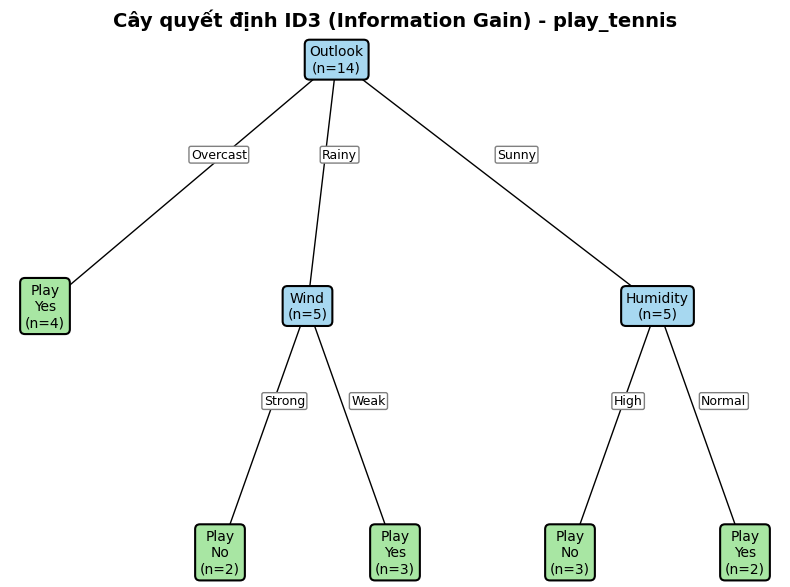


✓ Cell 5: Cây quyết định ID3 hoàn tất!


In [7]:
# Cell 5: Cây quyết định ID3 (Information Gain)
import pandas as pd
import math
from collections import Counter

print("="*90)
print("XÂY DỰNG CÂY QUYẾT ĐỊNH ID3 (INFORMATION GAIN)")
print("="*90)

# Chuẩn bị dữ liệu
df_work = df.copy()
feature_cols = [c for c in df.columns if c != target_label]

print(f"\nDữ liệu đầu vào:")
print(f"Số mẫu: {len(df_work)} | Thuộc tính quyết định: {target_label}")
print(f"Các thuộc tính: {feature_cols}")
print(f"\nBảng dữ liệu đầy đủ:")
print(df_work.to_string(index=False))

# =========================
# Hàm tính Information (Entropy) và Gain
# =========================
print("\n" + "="*90)
print("BƯỚC 1: TÍNH INFORMATION (ENTROPY)")
print("="*90)

def entropy(series):
    total = len(series)
    if total == 0:
        return 0.0
    counts = Counter(series)
    e = 0.0
    for count in counts.values():
        p = count / total
        if p > 0:
            e -= p * math.log2(p)
    return e


def information_gain(data, attr, decision_attr):
    info_decision = entropy(data[decision_attr])
    weighted_info = 0.0
    
    print(f"\n  Xét thuộc tính '{attr}':")
    print(f"  I({decision_attr}) = {info_decision:.6f}")
    
    for v, subset in data.groupby(attr):
        w = len(subset) / len(data)
        e = entropy(subset[decision_attr])
        weighted_info += w * e
        print(f"    {attr}={v}: |S|={len(subset)}/{len(data)}, I({decision_attr}|{attr}={v})={e:.6f}")
    
    gain = info_decision - weighted_info
    print(f"  => Weighted I({decision_attr}|{attr}) = {weighted_info:.6f}")
    print(f"  => Gain({attr}) = {info_decision:.6f} - {weighted_info:.6f} = {gain:.6f}")
    return info_decision, weighted_info, gain


def gain_table(data, attrs, decision_attr):
    rows = []
    info_decision = entropy(data[decision_attr])
    print(f"\nEntropy của {decision_attr}: I({decision_attr}) = {info_decision:.6f}")
    
    for a in attrs:
        _, weighted_info, g = information_gain(data, a, decision_attr)
        rows.append({
            'Thuộc tính': a,
            'I(sau chia)': round(weighted_info, 6),
            'Gain': round(g, 6)
        })
    table = pd.DataFrame(rows).sort_values('Gain', ascending=False).reset_index(drop=True)
    return info_decision, table


# =========================
# Xây dựng ID3
# =========================
class Node:
    def __init__(self, attribute=None, label=None):
        self.attribute = attribute
        self.label = label
        self.children = {}
        self.majority_label = None
        self.sample_count = 0


def id3(data, attrs, decision_attr, path_text='Gốc', depth=0):
    node = Node()
    node.sample_count = len(data)
    node.majority_label = data[decision_attr].mode()[0]

    print('\n' + '=' * 90)
    print(f"BƯỚC {depth + 1} | {path_text}")
    print(f"Số mẫu: {len(data)}")
    
    if depth == 0:
        print(f"\nDữ liệu tại node hiện tại:")
        print(data.to_string(index=False))

    # Điều kiện dừng 1: tập thuần nhất
    unique_labels = data[decision_attr].unique()
    if len(unique_labels) == 1:
        node.label = unique_labels[0]
        print(f"Tập thuần nhất -> tạo lá: {node.label}")
        return node

    # Điều kiện dừng 2: hết thuộc tính
    if not attrs:
        node.label = node.majority_label
        print(f"Hết thuộc tính -> tạo lá theo đa số: {node.label}")
        return node

    # Tính Gain
    info_decision, table = gain_table(data, attrs, decision_attr)
    print(f"\nBảng Gain:")
    print(table.to_string(index=False))

    # Chọn thuộc tính tốt nhất
    best_attr = table.iloc[0]['Thuộc tính']
    best_gain = table.iloc[0]['Gain']

    if best_gain <= 1e-12:
        node.label = node.majority_label
        print(f"Gain tối đa ~ 0 -> tạo lá theo đa số: {node.label}")
        return node

    node.attribute = best_attr
    print(f"\n=> Chọn thuộc tính phân lớp: {best_attr} (Gain = {best_gain:.6f})")

    # Lặp trên các bảng con
    remaining_attrs = [a for a in attrs if a != best_attr]
    for v in sorted(data[best_attr].unique()):
        subset = data[data[best_attr] == v]
        print(f"\nTách nhánh: {best_attr} = {v} | số mẫu = {len(subset)}")

        if subset.empty:
            leaf = Node(label=node.majority_label)
            leaf.sample_count = 0
            leaf.majority_label = node.majority_label
            node.children[v] = leaf
        else:
            child_path = f"{path_text} -> {best_attr}={v}"
            node.children[v] = id3(subset, remaining_attrs, decision_attr, child_path, depth + 1)

    return node


# =========================
# In cây
# =========================
def print_tree(node, indent=''):
    if node.label is not None:
        print(f"{indent}THEN {target_label} = {node.label} (mẫu: {node.sample_count})")
        return
    print(f"{indent}[Chia theo: {node.attribute}] (mẫu: {node.sample_count})")
    for value, child in node.children.items():
        print(f"{indent}IF {node.attribute} = {value}")
        print_tree(child, indent + '    ')


# =========================
# Vẽ cây
# =========================
import matplotlib.pyplot as plt

def count_leaves(node):
    if node.label is not None:
        return 1
    return sum(count_leaves(child) for child in node.children.values())

def tree_depth(node):
    if node.label is not None:
        return 1
    return 1 + max(tree_depth(child) for child in node.children.values())

def assign_positions(node, x=0, y=0, pos=None, edges=None, x_state=None):
    if pos is None:
        pos = {}
    if edges is None:
        edges = []
    if x_state is None:
        x_state = {'x': 0}
    node_id = id(node)
    if node.label is not None:
        pos[node_id] = (x_state['x'], -y)
        x_state['x'] += 1
    else:
        child_ids = []
        for val, child in node.children.items():
            assign_positions(child, y=y + 1, pos=pos, edges=edges, x_state=x_state)
            child_ids.append(id(child))
            edges.append((node_id, id(child), f"{val}"))
        child_x = [pos[cid][0] for cid in child_ids]
        pos[node_id] = (sum(child_x) / len(child_x), -y)
    return pos, edges

def draw_id3_tree(root_node):
    pos, edges = assign_positions(root_node)
    depth = tree_depth(root_node)
    leaves = count_leaves(root_node)
    fig_w = max(8, leaves * 1.2)
    fig_h = max(6, depth * 1.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    for parent, child, label in edges:
        x1, y1 = pos[parent]
        x2, y2 = pos[child]
        ax.plot([x1, x2], [y1, y2], color='black', linewidth=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.1, label, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.15'))
    def walk(node):
        nid = id(node)
        x, y = pos[nid]
        if node.label is not None:
            color = '#A8E6A3'
            text = f"{target_label}\n{node.label}\n(n={node.sample_count})"
        else:
            color = '#A7D8F0'
            text = f"{node.attribute}\n(n={node.sample_count})"
        ax.text(x, y, text, ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=color, edgecolor='black', linewidth=1.5))
        for c in node.children.values():
            walk(c)
    walk(root_node)
    ax.set_title('Cây quyết định ID3 (Information Gain) - play_tennis', fontsize=14, weight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# =========================
# CHẠY ID3 TRÊN play_tennis
# =========================
print('\n' + '=' * 90)
print('CHẠY THUẬT TOÁN ID3 TRÊN TOÀN BỘ play_tennis')
print('=' * 90)

root = id3(df_work, feature_cols, target_label)

print('\n' + '=' * 90)
print('CẤU TRÚC CÂY KẾT QUẢ')
print('=' * 90)
print_tree(root)

draw_id3_tree(root)

print("\n✓ Cell 5: Cây quyết định ID3 hoàn tất!")

GOM CỤM K-MEANS

Dữ liệu gốc:
Kích thước: (14, 4)
 Outlook Temperature Humidity   Wind
   Sunny         Hot     High   Weak
   Sunny         Hot     High Strong
Overcast         Hot     High   Weak
   Rainy        Mild     High   Weak
   Rainy        Cool   Normal   Weak
   Rainy        Cool   Normal Strong
Overcast        Cool   Normal Strong
   Sunny        Mild     High   Weak
   Sunny        Cool   Normal   Weak
   Rainy        Mild   Normal   Weak
   Sunny        Mild   Normal Strong
Overcast        Mild     High Strong
Overcast         Hot   Normal   Weak
   Rainy        Mild     High Strong

Sau one-hot encoding: 10 thuộc tính
Các cột: ['Outlook_Overcast', 'Outlook_Rainy', 'Outlook_Sunny', 'Temperature_Cool', 'Temperature_Hot', 'Temperature_Mild', 'Humidity_High', 'Humidity_Normal', 'Wind_Strong', 'Wind_Weak']

Chạy K-Means tự xây dựng với k=2...
-> Hội tụ tại vòng lặp thứ 3

Kết quả phân cụm:
Cluster sizes: [5 9]

Cụm 0 (5 mẫu):
  Mẫu 4: {'Outlook': 'Rainy', 'Temperature': 'Mil

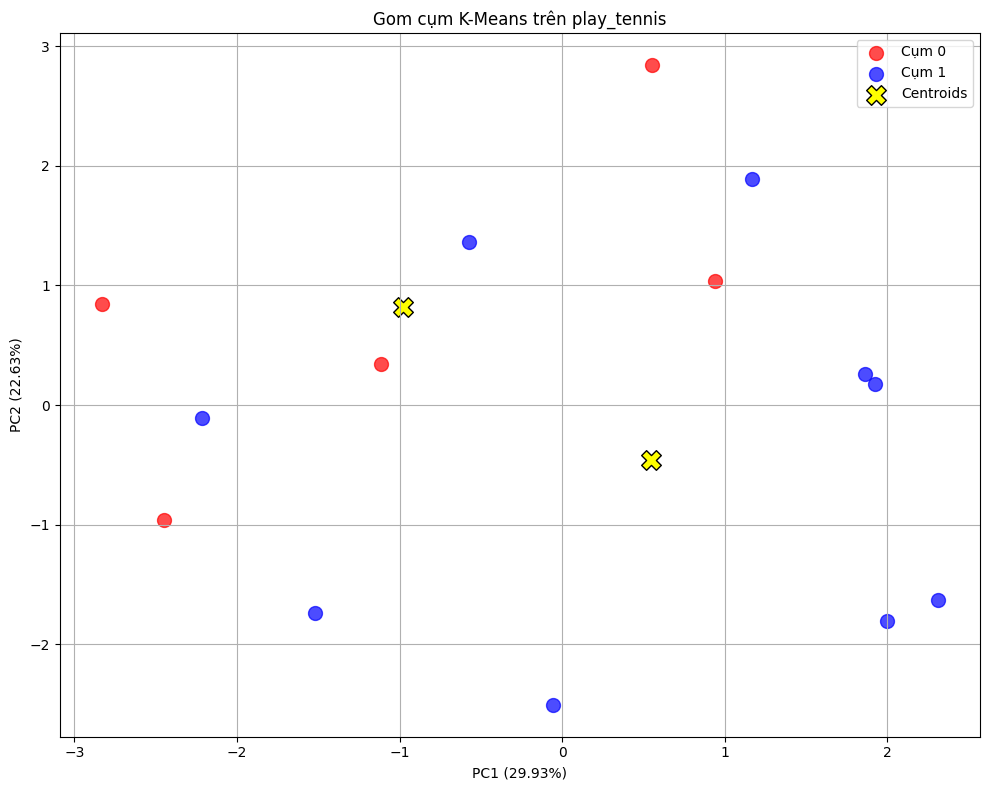


✓ Cell 6: Gom cụm K-Means hoàn tất!


In [8]:
# Cell 6: Gom cụm K-Means - Dùng one-hot encoding cho play_tennis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("="*80)
print("GOM CỤM K-MEANS")
print("="*80)

# Chuẩn bị dữ liệu - One-hot encoding cho categorical
X_raw = df.drop(target_label, axis=1).copy()
print(f"\nDữ liệu gốc:")
print(f"Kích thước: {X_raw.shape}")
print(X_raw.to_string(index=False))

# One-hot encoding
X_encoded = pd.get_dummies(X_raw, drop_first=False)
print(f"\nSau one-hot encoding: {X_encoded.shape[1]} thuộc tính")
print(f"Các cột: {X_encoded.columns.tolist()}")

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Xây dựng K-Means từ đầu
class CustomKMeans:
    def __init__(self, n_clusters=2, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.centroids = None
        self.labels = None

    def initialize_random_clusters(self, X):
        np.random.seed(42)
        n_samples = X.shape[0]
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices].copy()
        self.labels = np.random.randint(0, self.n_clusters, n_samples)
        initial_clusters = {i: [] for i in range(self.n_clusters)}
        for idx, label in enumerate(self.labels):
            initial_clusters[label].append(X[idx])
        for i in range(self.n_clusters):
            if len(initial_clusters[i]) > 0:
                self.centroids[i] = np.mean(initial_clusters[i], axis=0)
        return self.labels, self.centroids

    def fit(self, X):
        self.initialize_random_clusters(X)
        n_samples = X.shape[0]
        for iteration in range(self.max_iters):
            prev_labels = self.labels.copy()
            distances = np.zeros((n_samples, self.n_clusters))
            for i in range(self.n_clusters):
                distances[:, i] = np.linalg.norm(X - self.centroids[i], axis=1)
            self.labels = np.argmin(distances, axis=1)
            for i in range(self.n_clusters):
                cluster_points = X[self.labels == i]
                if len(cluster_points) > 0:
                    self.centroids[i] = np.mean(cluster_points, axis=0)
            if np.all(self.labels == prev_labels):
                print(f"-> Hội tụ tại vòng lặp thứ {iteration + 1}")
                break

# Chạy K-Means với k=2 (vì Play có 2 giá trị Yes/No)
k_optimal = 2
print(f"\nChạy K-Means tự xây dựng với k={k_optimal}...")
kmeans_custom = CustomKMeans(n_clusters=k_optimal, max_iters=100)
kmeans_custom.fit(X_scaled)

clusters = kmeans_custom.labels

print(f"\nKết quả phân cụm:")
print(f"Cluster sizes: {np.bincount(clusters)}")
for i in range(k_optimal):
    mask = clusters == i
    print(f"\nCụm {i} ({np.sum(mask)} mẫu):")
    for idx in np.where(mask)[0]:
        print(f"  Mẫu {idx+1}: {dict(zip(X_raw.columns, X_raw.iloc[idx].values))} -> {target_label}={df[target_label].iloc[idx]}")

# Đánh giá
if len(np.unique(clusters)) >= 2:
    silhouette = silhouette_score(X_scaled, clusters)
    davies_bouldin = davies_bouldin_score(X_scaled, clusters)
    print(f"\nĐánh giá:")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")

# Visualize
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans_custom.centroids)

plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'orange']
for i in range(k_optimal):
    mask = clusters == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=f'Cụm {i}', alpha=0.7, s=100)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='yellow', marker='X', s=200, edgecolors='black', label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('Gom cụm K-Means trên play_tennis')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✓ Cell 6: Gom cụm K-Means hoàn tất!")

THUẬT TOÁN KOHONEN SELF-ORGANIZING MAP TRÊN play_tennis

Dữ liệu sau one-hot encoding: 10 chiều
Các chiều: ['Outlook_Overcast', 'Outlook_Rainy', 'Outlook_Sunny', 'Temperature_Cool', 'Temperature_Hot', 'Temperature_Mild', 'Humidity_High', 'Humidity_Normal', 'Wind_Strong', 'Wind_Weak']

Số mẫu: 14 | Số chiều: 10

BƯỚC 0: Khởi tạo giá trị của các vector trọng số
✓ Mạng lưới Kohonen: 4x4 (16 nơ-ron)
✓ Bán kính ban đầu R = 2.00
✓ Tốc độ học α = 0.5

LẦN LẶP THỨ 1
  Thay đổi trung bình: 89.155952
  α mới: 0.250000, R mới: 1.9000

LẦN LẶP THỨ 2
  Thay đổi trung bình: 35.684986
  α mới: 0.125000, R mới: 1.8050

LẦN LẶP THỨ 3
  Thay đổi trung bình: 14.920726
  α mới: 0.062500, R mới: 1.7147

LẦN LẶP THỨ 4
  Thay đổi trung bình: 6.512249
  α mới: 0.031250, R mới: 1.6290

LẦN LẶP THỨ 5
  Thay đổi trung bình: 2.868442
  α mới: 0.015625, R mới: 1.5476

LẦN LẶP THỨ 6
  Thay đổi trung bình: 1.370995
  α mới: 0.007812, R mới: 1.4702

LẦN LẶP THỨ 7
  Thay đổi trung bình: 0.708724
  α mới: 0.003906, R m

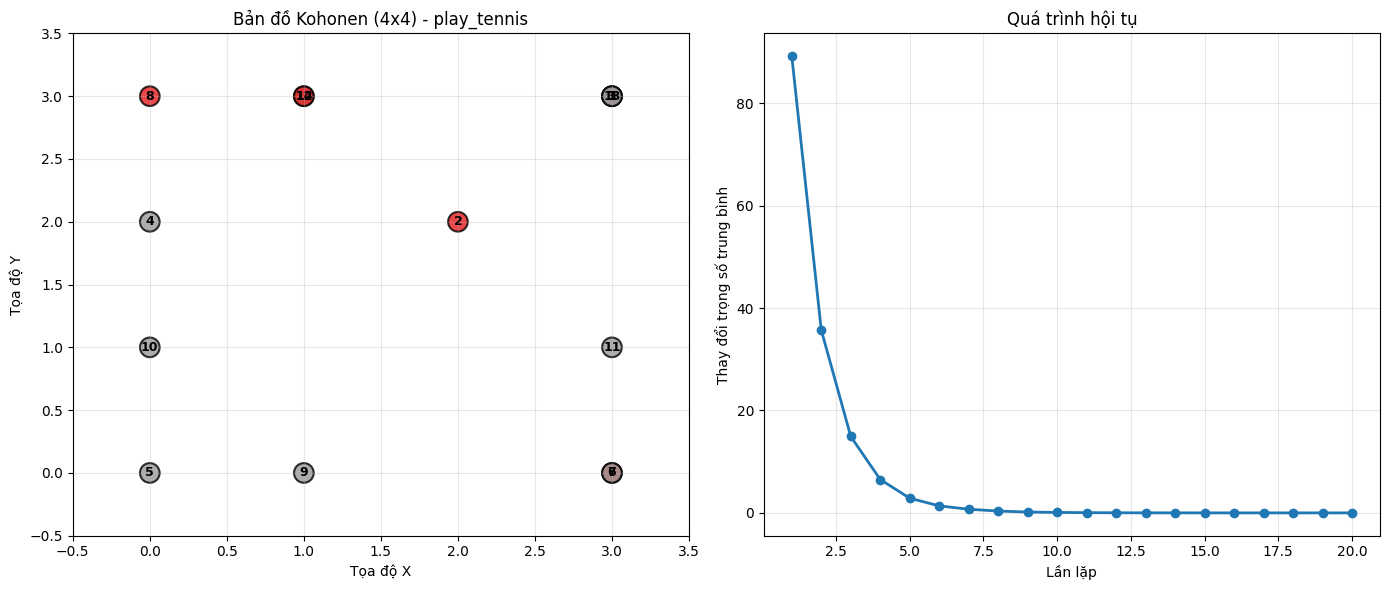


✓ Cell 7: Gom cụm mạng Kohonen hoàn tất!


In [9]:
# Cell 7: Gom cum Mang Kohonen (Self-Organizing Map)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

print("=" * 100)
print("THUẬT TOÁN KOHONEN SELF-ORGANIZING MAP TRÊN play_tennis")
print("=" * 100)

# Chuẩn bị dữ liệu
X = df.drop(target_label, axis=1).copy()
y_true = df[target_label]

# One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=False)
print(f"\nDữ liệu sau one-hot encoding: {X_encoded.shape[1]} chiều")
print(f"Các chiều: {X_encoded.columns.tolist()}")

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded).astype(np.float32)

num_features = X_scaled.shape[1]
num_samples = X_scaled.shape[0]
print(f"\nSố mẫu: {num_samples} | Số chiều: {num_features}")

# ==================== BƯỚC 0: KHỞI TẠO ====================
print("\n" + "=" * 100)
print("BƯỚC 0: Khởi tạo giá trị của các vector trọng số")
print("=" * 100)

rows, cols = 4, 4
map_size = (rows, cols)
R = max(rows, cols) / 2
alpha = 0.5
max_iterations = 20

np.random.seed(42)
weights = np.random.uniform(-1, 1, (rows, cols, num_features)).astype(np.float32)

print(f"✓ Mạng lưới Kohonen: {rows}x{cols} ({rows*cols} nơ-ron)")
print(f"✓ Bán kính ban đầu R = {R:.2f}")
print(f"✓ Tốc độ học α = {alpha}")

# ==================== BƯỚC 1-8: LẶP HUẤN LUYỆN ====================
iteration = 1
convergence_threshold = 1e-5
prev_weights = weights.copy()
weight_changes = []

while iteration <= max_iterations:
    print("\n" + "=" * 100)
    print(f"LẦN LẶP THỨ {iteration}")
    print("=" * 100)
    
    iteration_changes = []
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    
    for sample_count, idx in enumerate(indices):
        x = X_scaled[idx]
        
        # BƯỚC 3: Tính khoảng cách
        distances = np.zeros((rows, cols))
        for i in range(rows):
            for j in range(cols):
                distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))
        
        # BƯỚC 4: Tìm nơron chiến thắng
        winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)
        
        # BƯỚC 5: Cập nhật trọng số
        for i in range(rows):
            for j in range(cols):
                neuron_distance = np.sqrt((i - winner_i) ** 2 + (j - winner_j) ** 2)
                if neuron_distance <= R:
                    weights[i, j] += alpha * (x - weights[i, j])
        
        iteration_changes.append(np.sum(np.abs(weights - prev_weights)))
    
    prev_weights = weights.copy()
    avg_change = np.mean(iteration_changes)
    weight_changes.append(avg_change)
    
    # BƯỚC 6: Cập nhật α
    alpha = 0.5 * alpha
    # BƯỚC 7: Giảm bán kính R
    R = R * 0.95
    
    print(f"  Thay đổi trung bình: {avg_change:.6f}")
    print(f"  α mới: {alpha:.6f}, R mới: {R:.4f}")
    
    # BƯỚC 8: Kiểm tra hội tụ
    if avg_change < convergence_threshold:
        print(f"\n✓ Hội tụ tại lần lặp {iteration}")
        break
    iteration += 1

print("\n✓ Huấn luyện hoàn tất!")

# ==================== GÁN CỤM ====================
print("\n" + "=" * 100)
print("GÁN CỤM DỮ LIỆU")
print("=" * 100)

winning_neurons = np.zeros((num_samples, 2), dtype=int)
for sample_idx in range(num_samples):
    x = X_scaled[sample_idx]
    distances = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))
    winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)
    winning_neurons[sample_idx] = [winner_i, winner_j]

print(f"\nPhân bố mẫu trên bản đồ Kohonen:")
for i in range(rows):
    for j in range(cols):
        mask = (winning_neurons[:, 0] == i) & (winning_neurons[:, 1] == j)
        count = np.sum(mask)
        if count > 0:
            samples_in_cell = np.where(mask)[0] + 1
            play_values = y_true.iloc[np.where(mask)[0]].values
            print(f"  Nơron ({i},{j}): {count} mẫu (mẫu {samples_in_cell.tolist()}) - Play: {play_values.tolist()}")

# ==================== VISUALIZATION ====================
print("\n" + "=" * 100)
print("HIỂN THỊ KẾT QUẢ")
print("=" * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Phân phối mẫu
ax = axes[0]
y_codes = pd.factorize(y_true.astype(str))[0]
ax.scatter(winning_neurons[:, 0], winning_neurons[:, 1], c=y_codes, cmap='Set1', s=200, alpha=0.8, edgecolors='black', linewidth=1.5)
for idx, (i, j) in enumerate(winning_neurons):
    ax.text(i, j, str(idx+1), ha='center', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Tọa độ X')
ax.set_ylabel('Tọa độ Y')
ax.set_title('Bản đồ Kohonen (4x4) - play_tennis')
ax.set_xlim([-0.5, cols - 0.5])
ax.set_ylim([-0.5, rows - 0.5])
ax.grid(True, alpha=0.3)

# Plot 2: Thay đổi trọng số
ax = axes[1]
ax.plot(range(1, len(weight_changes) + 1), weight_changes, marker='o', linewidth=2, markersize=6)
ax.set_xlabel('Lần lặp')
ax.set_ylabel('Thay đổi trọng số trung bình')
ax.set_title('Quá trình hội tụ')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Cell 7: Gom cụm mạng Kohonen hoàn tất!")

SO SÁNH KẾT QUẢ GOM CỤM: K-MEANS vs KOHONEN (SOM)
✓ Dữ liệu: 14 mẫu, 10 thuộc tính (one-hot)

🟢 Huấn luyện Kohonen SOM...
Phân bố mẫu theo nơron chiến thắng:
  Nơron (1,0) -> Cụm 0: mẫu [1, 2, 8]
  Nơron (0,0) -> Cụm 1: mẫu [3, 13]
  Nơron (1,1) -> Cụm 2: mẫu [4, 11, 12, 14]
  Nơron (0,1) -> Cụm 3: mẫu [5, 6, 7, 9, 10]

🔵 Huấn luyện K-Means...
✓ K-Means: k=4

BẢNG SO SÁNH METRICS
  Phương pháp  Silhouette  Davies-Bouldin  Calinski-Harabasz  n_clusters
      K-Means      0.1769          1.2622             3.6393           4
Kohonen (SOM)      0.1639          1.2851             3.4820           4


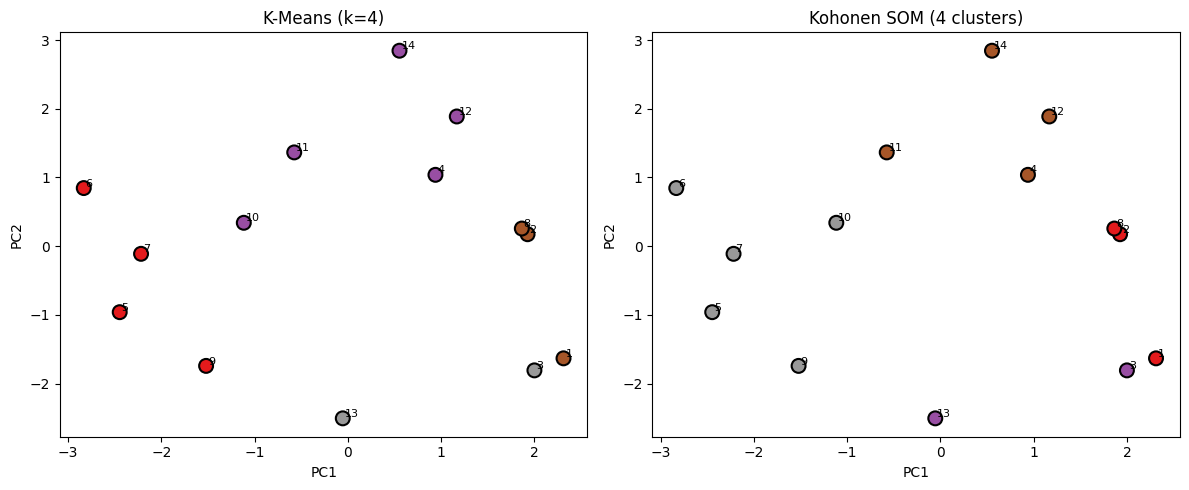


✓ So sánh K-Means vs Kohonen hoàn tất!


In [10]:
# Cell 8: So sánh K-Means và Kohonen (SOM)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("=" * 100)
print("SO SÁNH KẾT QUẢ GOM CỤM: K-MEANS vs KOHONEN (SOM)")
print("=" * 100)

# 1) Dữ liệu chung
X = df.drop(target_label, axis=1).copy()
X_encoded = pd.get_dummies(X, drop_first=False)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded).astype(np.float32)
print(f"✓ Dữ liệu: {X_scaled.shape[0]} mẫu, {X_scaled.shape[1]} thuộc tính (one-hot)")

# 2) Kohonen SOM (2x2 để so sánh)
print("\n🟢 Huấn luyện Kohonen SOM...")
map_size_x, map_size_y = 2, 2
R = max(map_size_x, map_size_y) / 2
alpha = 0.5
max_iterations = 30
np.random.seed(42)
weights = np.random.uniform(-1, 1, (map_size_x, map_size_y, X_scaled.shape[1])).astype(np.float32)
prev_weights = weights.copy()
for _ in range(max_iterations):
    for row in range(X_scaled.shape[0]):
        x = X_scaled[row]
        distances = np.zeros((map_size_x, map_size_y), dtype=np.float32)
        for i in range(map_size_x):
            for j in range(map_size_y):
                distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))
        winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)
        for i in range(map_size_x):
            for j in range(map_size_y):
                neuron_distance = np.sqrt((i - winner_i) ** 2 + (j - winner_j) ** 2)
                if neuron_distance <= R:
                    weights[i, j] += alpha * (x - weights[i, j])
    avg_change = float(np.mean(np.abs(weights - prev_weights)))
    prev_weights = weights.copy()
    alpha *= 0.5
    R *= 0.95
    if avg_change < 1e-4:
        break

winning_neurons = np.zeros((X_scaled.shape[0], 2), dtype=int)
for row in range(X_scaled.shape[0]):
    x = X_scaled[row]
    distances = np.zeros((map_size_x, map_size_y), dtype=np.float32)
    for i in range(map_size_x):
        for j in range(map_size_y):
            distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))
    winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)
    winning_neurons[row] = [winner_i, winner_j]

cluster_map = {}
kohonen_labels = np.zeros(X_scaled.shape[0], dtype=int)
label_counter = 0
for idx, (i, j) in enumerate(winning_neurons):
    key = (int(i), int(j))
    if key not in cluster_map:
        cluster_map[key] = label_counter
        label_counter += 1
    kohonen_labels[idx] = cluster_map[key]
kohonen_k = int(len(np.unique(kohonen_labels)))

print(f"Phân bố mẫu theo nơron chiến thắng:")
for (i, j), label in cluster_map.items():
    mask = kohonen_labels == label
    indices = np.where(mask)[0] + 1
    print(f"  Nơron ({i},{j}) -> Cụm {label}: mẫu {indices.tolist()}")

# 3) K-Means
print("\n🔵 Huấn luyện K-Means...")
kmeans_k = max(2, kohonen_k)
kmeans = KMeans(n_clusters=kmeans_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
print(f"✓ K-Means: k={kmeans_k}")

# 4) Metrics
def safe_metrics(labels):
    unique = np.unique(labels)
    if len(unique) < 2:
        return {'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan, 'n_clusters': len(unique)}
    return {
        'Silhouette': float(silhouette_score(X_scaled, labels)),
        'Davies-Bouldin': float(davies_bouldin_score(X_scaled, labels)),
        'Calinski-Harabasz': float(calinski_harabasz_score(X_scaled, labels)),
        'n_clusters': len(unique),
    }

comparison = pd.DataFrame([
    {'Phương pháp': 'K-Means', **safe_metrics(kmeans_labels)},
    {'Phương pháp': 'Kohonen (SOM)', **safe_metrics(kohonen_labels)},
])

print("\n" + "=" * 100)
print("BẢNG SO SÁNH METRICS")
print("=" * 100)
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# 5) Trực quan
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=100, cmap='Set1', edgecolors='black', linewidth=1.5)
for idx, (x, y) in enumerate(X_pca):
    axes[0].text(x+0.02, y+0.02, str(idx+1), fontsize=8)
axes[0].set_title(f'K-Means (k={kmeans_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kohonen_labels, s=100, cmap='Set1', edgecolors='black', linewidth=1.5)
for idx, (x, y) in enumerate(X_pca):
    axes[1].text(x+0.02, y+0.02, str(idx+1), fontsize=8)
axes[1].set_title(f'Kohonen SOM ({kohonen_k} clusters)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

print("\n✓ So sánh K-Means vs Kohonen hoàn tất!")